In [1]:
import torch
import matplotlib.pyplot as plt
from model import mnistINR
from dataset import OptimizedDataset

/home/theseeker/miniconda3/envs/neural-graphs/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/theseeker/miniconda3/envs/neural-graphs/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
#Preparing the canvas for MLP-Query
h, w = 28, 28
y = torch.linspace(0, 1, h)
x = torch.linspace(0, 1, w)
grid_y, grid_x = torch.meshgrid(y, x, indexing='ij')
coords = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=-1)

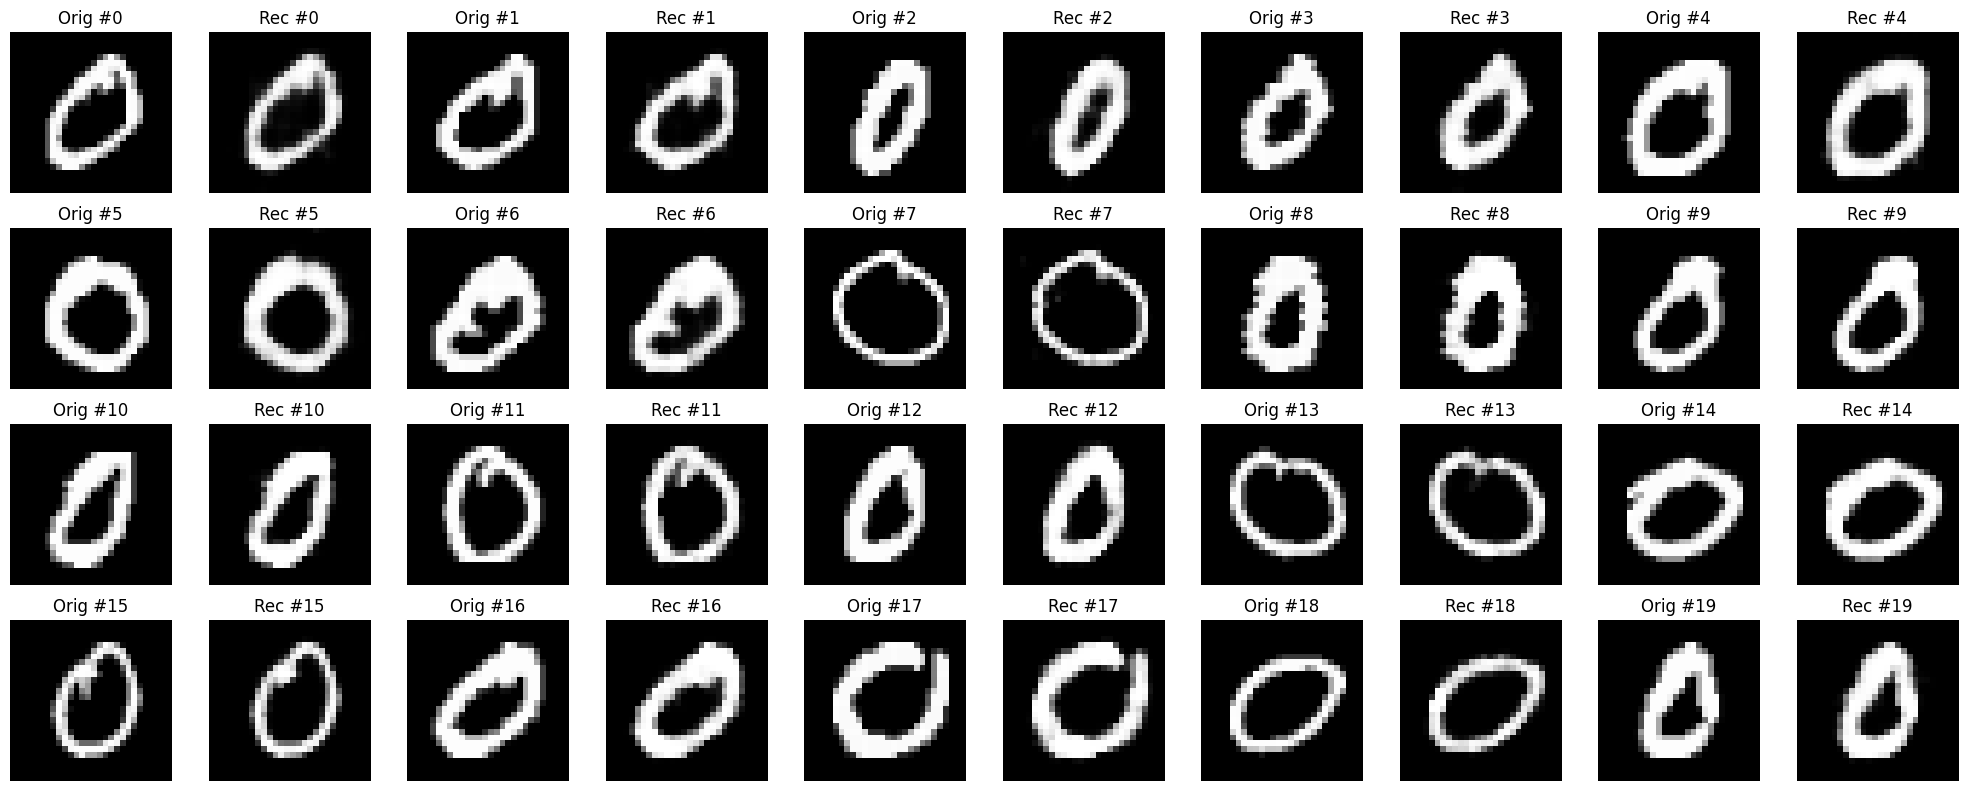

In [3]:
train_ds = OptimizedDataset(as_inr=True)

fig, axes = plt.subplots(4, 10, figsize=(20, 8)) # 4 rows, 10 columns for pairs
axes = axes.flatten()

for i in range(20): # Visualizing the first 10 pairs (Original + Reconstruction)
    # 1. Get Original
    coords, target, label = train_ds[i]
    original = target.view(28, 28)
    
    # 2. Load Model & Get Reconstruction
    model_path = f"checkpoints/model_sample_{i}_digit_0.pth"
    model = mnistINR()
    model.load_state_dict(torch.load(model_path, map_location='cpu'))
    model.eval()
    
    with torch.no_grad():
        reconstruction = model(coords).view(28, 28)
    
    # 3. Plot Original
    axes[i*2].imshow(original.numpy(), cmap='gray')
    axes[i*2].set_title(f"Orig #{i}")
    axes[i*2].axis('off')
    
    # 4. Plot Reconstruction
    axes[i*2+1].imshow(reconstruction.numpy(), cmap='gray')
    axes[i*2+1].set_title(f"Rec #{i}")
    axes[i*2+1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
h, w = 512, 512
y = torch.linspace(0, 1, h)
x = torch.linspace(0, 1, w)
grid_y, grid_x = torch.meshgrid(y, x, indexing='ij')
coords = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=-1)

model_path = f"checkpoints/model_sample_0_digit_0.pth"
model = mnistINR()
model.load_state_dict(torch.load(model_path, map_location='cpu'))
model.eval()

with torch.no_grad():
    reconstruction = model(coords).view(512, 512)
plt.imshow(reconstruction.numpy(), cmap='gray')


RuntimeError: shape '[128, 128]' is invalid for input of size 262144